In [ ]:
# =========================================================
# EfficientNet-B2 (transfer learning) para 4 classes
# =========================================================
!pip -q install torch torchvision scikit-learn

import os, numpy as np, matplotlib.pyplot as plt, warnings, random
from pathlib import Path
warnings.filterwarnings("ignore")

import torch, torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, f1_score, classification_report

# ----------------------------
# Reprodutibilidade básica
# ----------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = torch.cuda.is_available()  # ativa AMP apenas se houver GPU
print("Device:", device, "| AMP:", use_amp)

# ============================
# Caminho do dataset
# ============================
DATA_ROOT = Path('/home/gustavom/Documents/Orange/Brain Tumor MRI Dataset/Training')   # ajuste se necessário
assert DATA_ROOT.exists(), f"Pasta {DATA_ROOT} não encontrada. Suba/extrai seu dataset."

# Detecta split pré-definido (train/validation)
use_predefined_split = (DATA_ROOT/"train").exists() and (DATA_ROOT/"validation").exists()

Device: cpu | AMP: False


In [ ]:
# ============================
# Transforms corretos p/ B2
# ============================
weights = EfficientNet_B2_Weights.IMAGENET1K_V1
preprocess = weights.transforms()  # Resize/CenterCrop(288), ToTensor, Normalize
train_tfms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    preprocess
])
val_tfms = preprocess

# ============================
# Datasets e DataLoaders
# ============================
if use_predefined_split:
    train_ds = datasets.ImageFolder(DATA_ROOT/"train", transform=train_tfms)
    val_ds   = datasets.ImageFolder(DATA_ROOT/"validation", transform=val_tfms)
    class_names = train_ds.classes
else:
    # Pasta única -> split estratificado 80/20
    base_no_tfms = datasets.ImageFolder(DATA_ROOT)  # só para rótulos
    class_names = base_no_tfms.classes
    targets = [y for _, y in base_no_tfms.samples]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_idx, val_idx = next(sss.split(np.zeros(len(targets)), targets))

    # Cria duas visões do mesmo conjunto com transforms distintos
    train_all = datasets.ImageFolder(DATA_ROOT, transform=train_tfms)
    val_all   = datasets.ImageFolder(DATA_ROOT, transform=val_tfms)
    train_ds = Subset(train_all, train_idx)
    val_ds   = Subset(val_all,   val_idx)

print("Classes:", class_names)

batch_size = 16  # imagens 288x288 consomem mais VRAM; ajuste se necessário
num_workers = 2 if torch.cuda.is_available() else 0
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers)


Classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


In [ ]:
# ============================
# Modelo: EfficientNet-B2
# ============================
model = efficientnet_b2(weights=weights)

# Congela extrator de features para treino rápido/estável
for p in model.features.parameters():
    p.requires_grad = False

# Substitui a última camada para 4 classes
num_classes = 4
in_feats = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_feats, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 104MB/s]


In [ ]:
# ============================
# Funções utilitárias
# ============================
def run_epoch(model, loader, train=True):
    model.train(mode=train)
    total_loss, total_correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []

    for X, y in loader:
        X, y = X.to(device), y.to(device)

        if train:
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(X)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            with torch.no_grad():
                logits = model(X)
                loss = criterion(logits, y)

        preds = logits.argmax(1)
        total_loss += loss.item() * y.size(0)
        total_correct += (preds == y).sum().item()
        total += y.size(0)
        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())

    avg_loss = total_loss / total
    acc = total_correct / total
    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    f1 = f1_score(y_true, y_pred, average='macro')
    return avg_loss, acc, f1, y_true, y_pred

def plot_curve(hist, k1, k2, title, ylab):
    plt.figure(figsize=(6,4))
    plt.plot(hist[k1], label=k1)
    plt.plot(hist[k2], label=k2)
    plt.xlabel("epoch"); plt.ylabel(ylab); plt.title(title); plt.legend(); plt.show()

def plot_cm(cm, classes, normalize=False, title="Confusion Matrix"):
    if normalize:
        cm = cm.astype(float)/cm.sum(axis=1, keepdims=True)
    import itertools
    plt.figure(figsize=(6,4))
    plt.imshow(cm, interpolation='nearest'); plt.title(title); plt.colorbar()
    ticks = np.arange(len(classes)); plt.xticks(ticks, classes, rotation=45); plt.yticks(ticks, classes)
    fmt = ".2f" if normalize else "d"; thresh = cm.max()/2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i,j], fmt), ha="center",
                 color="white" if cm[i,j] > thresh else "black")
    plt.ylabel("True"); plt.xlabel("Pred"); plt.tight_layout(); plt.show()


In [ ]:
# ============================
# Treinamento
# ============================
EPOCHS = 3  # aumente para 5–10 se quiser refinar
history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[], "val_f1":[]}

for e in range(1, EPOCHS+1):
    tr_loss, tr_acc, _, _, _ = run_epoch(model, train_loader, train=True)
    va_loss, va_acc, va_f1, y_true, y_pred = run_epoch(model, val_loader, train=False)

    history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc); history["val_f1"].append(va_f1)

    print(f"[{e}/{EPOCHS}] "
          f"train_loss={tr_loss:.4f} acc={tr_acc:.4f} | "
          f"val_loss={va_loss:.4f} acc={va_acc:.4f} f1={va_f1:.4f}")

[1/3] train_loss=0.5468 acc=0.7889 | val_loss=0.4806 acc=0.8164 f1=0.8150
[2/3] train_loss=0.5457 acc=0.7975 | val_loss=0.4643 acc=0.8164 f1=0.8133
[3/3] train_loss=0.5183 acc=0.8037 | val_loss=0.4688 acc=0.8306 f1=0.8301


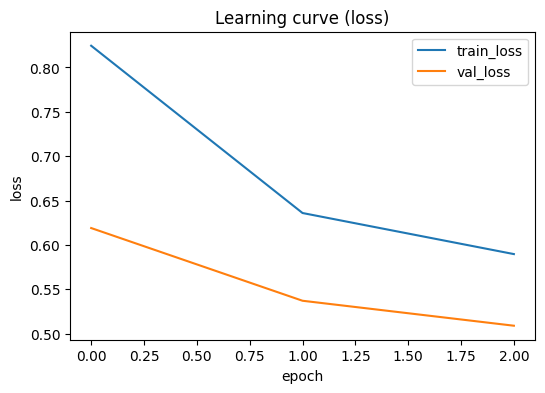

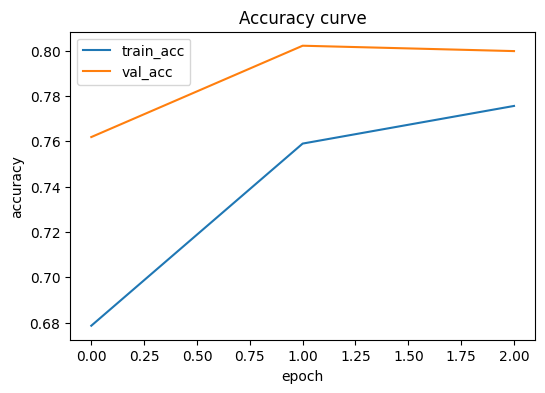


Validation metrics:
Accuracy: 0.7998 | F1 (macro): 0.7981

Classification report:
                       precision    recall  f1-score   support

            cataract       0.82      0.90      0.86       208
diabetic_retinopathy       0.93      0.79      0.86       220
            glaucoma       0.76      0.67      0.71       201
              normal       0.72      0.83      0.77       215

            accuracy                           0.80       844
           macro avg       0.81      0.80      0.80       844
        weighted avg       0.81      0.80      0.80       844



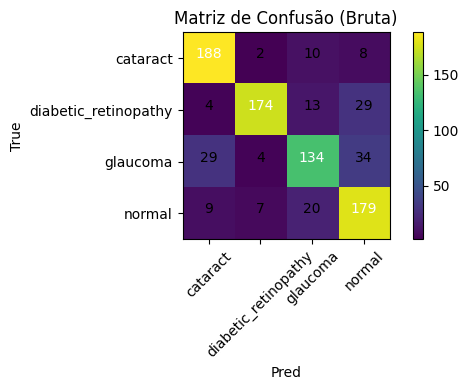

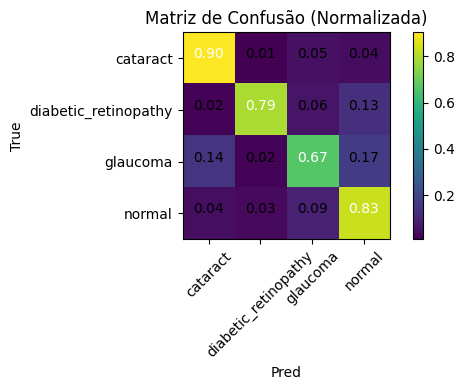

In [ ]:
# ============================
# Curvas e métricas finais
# ============================
plot_curve(history, "train_loss", "val_loss", "Learning curve (loss)", "loss")
plot_curve(history, "train_acc",  "val_acc",  "Accuracy curve",       "accuracy")

print("\nValidation metrics:")
print(f"Accuracy: {history['val_acc'][-1]:.4f} | F1 (macro): {history['val_f1'][-1]:.4f}")
print("\nClassification report:\n", classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plot_cm(cm, class_names, normalize=False, title="Matriz de Confusão (Bruta)")
plot_cm(cm, class_names, normalize=True,  title="Matriz de Confusão (Normalizada)")